### Import all packages need in the cell below

In [22]:
using Plots
using Ipopt
using GLPK
using GLM, DataFrames
using LinearAlgebra
using HiGHS

LoadError: ArgumentError: Package GLPK not found in current path.
- Run `import Pkg; Pkg.add("GLPK")` to install the GLPK package.

# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

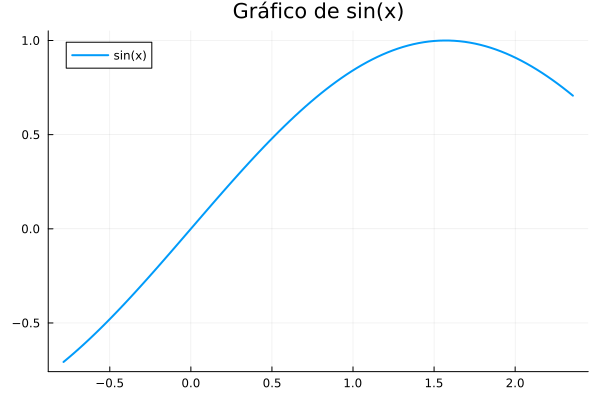

In [23]:
x = range(-pi/4, 3*pi/4, length=100)
y = sin.(x)
plot(x, y, title="Gráfico de sin(x)", label="sin(x)", lw=2)

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

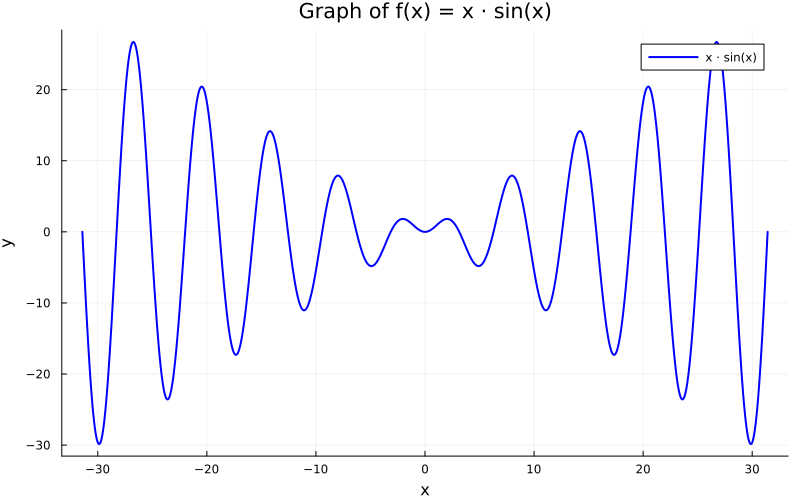

In [24]:
using Plots

x = range(-10π, 10π, length=1000)
y = x .* sin.(x)

plot(x, y,
    label       = "x · sin(x)",
    xlabel      = "x",
    ylabel      = "y",
    title       = "Graph of f(x) = x · sin(x)",
    linewidth   = 2,
    color       = :blue,
    legend      = :topright,
    grid        = true,
    size        = (800, 500)
)


# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

  Cylinder Problem — Resultados
Status : LOCALLY_SOLVED
Raio   : 1.333333
Altura : 1.333333
Volume : 7.446738


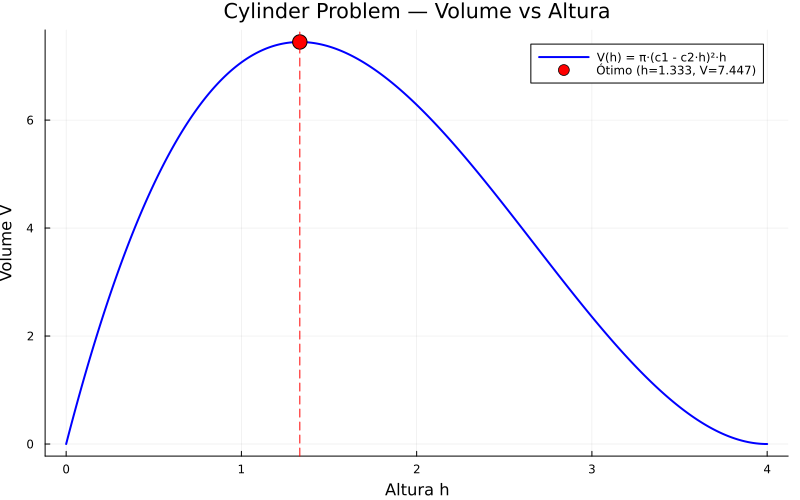

In [25]:
using JuMP
using Ipopt
using Plots

# ── Dados ─────────────────────────────────────────────────────────
N  = 10
c1 = 2
c2 = 0.5

# ── Modelo ────────────────────────────────────────────────────────
model = Model(Ipopt.Optimizer)
set_attribute(model, "print_level", 0)

@variable(model, r >= 0)
@variable(model, h >= 0)

@constraint(model, r <= c1 - c2 * h)
@constraint(model, h <= N)

@NLobjective(model, Max, π * r^2 * h)

set_start_value(r, 1.0)
set_start_value(h, 2.0)

optimize!(model)

r_opt = value(r)
h_opt = value(h)
V_opt = objective_value(model)

println("="^40)
println("  Cylinder Problem — Resultados")
println("="^40)
println("Status : ", termination_status(model))
println("Raio   : ", round(r_opt, digits=6))
println("Altura : ", round(h_opt, digits=6))
println("Volume : ", round(V_opt, digits=6))
println("="^40)

# ── Gráfico: Volume em função de h ────────────────────────────────
# Para cada h, o raio ótimo é r = c1 - c2*h (restrição ativa)
# V(h) = π * (c1 - c2*h)² * h,  para 0 ≤ h ≤ c1/c2

h_max_geom = c1 / c2          # h onde r = 0
h_vals = range(0, h_max_geom, length=500)
V_vals = [π * (c1 - c2*h)^2 * h for h in h_vals]

plot(h_vals, V_vals,
    label     = "V(h) = π·(c1 - c2·h)²·h",
    xlabel    = "Altura h",
    ylabel    = "Volume V",
    title     = "Cylinder Problem — Volume vs Altura",
    linewidth = 2,
    color     = :blue,
    grid      = true,
    size      = (800, 500)
)

# Ponto ótimo
scatter!([h_opt], [V_opt],
    label      = "Ótimo (h=$(round(h_opt,digits=3)), V=$(round(V_opt,digits=3)))",
    color      = :red,
    markersize = 8
)

# Linha vertical no ponto ótimo
vline!([h_opt],
    label     = "",
    color     = :red,
    linestyle = :dash,
    linewidth = 1
)


# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

  Awning Problem — Resultados
Status  : LOCALLY_SOLVED
x ótimo : 1.5
y ótimo : 1.0
Área máx: 1.5

  Verificação da restrição:
  x/w + y/h = 1.0 ≤ 1


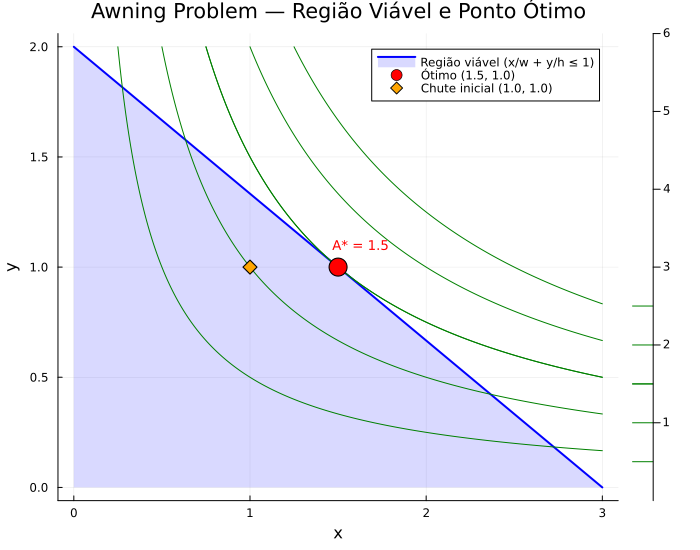

In [26]:
using JuMP
using Ipopt
using Plots

# ── Dados ─────────────────────────────────────────────────────────
h = 2.0   # altura da parede
w = 3.0   # largura da parede
x0, y0 = 1.0, 1.0   # chute inicial

# ── Modelo ────────────────────────────────────────────────────────
model = Model(Ipopt.Optimizer)
set_attribute(model, "print_level", 0)

@variable(model, x >= 0)
@variable(model, y >= 0)

# Restrição: ponto (x,y) deve estar abaixo da reta x/w + y/h = 1
@constraint(model, x/w + y/h <= 1)

# Objetivo: maximizar área = x * y
@NLobjective(model, Max, x * y)

set_start_value(x, x0)
set_start_value(y, y0)

optimize!(model)

x_opt = value(x)
y_opt = value(y)
A_opt = objective_value(model)

println("="^42)
println("  Awning Problem — Resultados")
println("="^42)
println("Status  : ", termination_status(model))
println("x ótimo : ", round(x_opt, digits=6))
println("y ótimo : ", round(y_opt, digits=6))
println("Área máx: ", round(A_opt, digits=6))
println()
println("  Verificação da restrição:")
println("  x/w + y/h = ",
    round(x_opt/w + y_opt/h, digits=6), " ≤ 1")
println("="^42)

# ── Gráfico ───────────────────────────────────────────────────────
# Região viável: x/w + y/h ≤ 1
x_line = range(0, w, length=300)
y_line = [h * (1 - xi/w) for xi in x_line]

# Curvas de nível da área A = x*y (hipérboles)
x_grid = range(0.01, w, length=400)
y_grid = range(0.01, h, length=400)
A_grid = [xi * yi for yi in y_grid, xi in x_grid]

plot(size=(700, 550), xlabel="x", ylabel="y",
     title="Awning Problem — Região Viável e Ponto Ótimo",
     legend=:topright, grid=true)

# Região viável preenchida
plot!(x_line, y_line,
    fillrange = zeros(length(x_line)),
    fillalpha = 0.15,
    fillcolor = :blue,
    color     = :blue,
    linewidth = 2,
    label     = "Região viável (x/w + y/h ≤ 1)")

# Curvas de nível
contour!(x_grid, y_grid, A_grid,
    levels    = [0.5, 1.0, 1.5, 2.0, 2.5, round(A_opt, digits=2)],
    color     = :green,
    linewidth = 1,
    label     = "Curvas A = x·y")

# Ponto ótimo
scatter!([x_opt], [y_opt],
    color      = :red,
    markersize = 10,
    label      = "Ótimo ($(round(x_opt,digits=3)), $(round(y_opt,digits=3)))")

# Chute inicial
scatter!([x0], [y0],
    color      = :orange,
    markersize = 7,
    markershape = :diamond,
    label      = "Chute inicial ($x0, $y0)")

# Anotação
annotate!(x_opt + 0.1, y_opt + 0.1,
    ("  A* = $(round(A_opt, digits=3))", 9, :red))



# Problem Statement

Solve the Packing Problem

In [27]:
using JuMP
using Ipopt
using Plots

# ── Dados ─────────────────────────────────────────────────────────
# Contêiner: caixa quadrada [0, L] x [0, L]
L = 10.0        # lado do contêiner
n = 5           # número de círculos a empacotar

# ── Modelo ────────────────────────────────────────────────────────
model = Model(Ipopt.Optimizer)
set_attribute(model, "print_level", 0)

# Variáveis: posição (cx, cy) e raio r de cada círculo
# Todos os círculos têm o mesmo raio r (maximizar r)
@variable(model, r >= 0)
@variable(model, cx[1:n])
@variable(model, cy[1:n])

# Objetivo: maximizar o raio comum
@objective(model, Max, r)

# Restrição 1: círculos dentro do contêiner
for i in 1:n
    @constraint(model, cx[i] >= r)
    @constraint(model, cx[i] <= L - r)
    @constraint(model, cy[i] >= r)
    @constraint(model, cy[i] <= L - r)
end

# Restrição 2: círculos não se sobrepõem
# distância entre centros >= 2r
for i in 1:n
    for j in (i+1):n
        @NLconstraint(model,
            (cx[i] - cx[j])^2 + (cy[i] - cy[j])^2 >= (2r)^2)
    end
end

# ── Chute inicial: disposição em grade ───────────────────────────
cols = ceil(Int, sqrt(n))
rows = ceil(Int, n / cols)
spacing = L / (cols + 1)

for i in 1:n
    col = mod(i-1, cols) + 1
    row = div(i-1, cols) + 1
    set_start_value(cx[i], col * spacing)
    set_start_value(cy[i], row * spacing)
end
set_start_value(r, spacing / 2 - 0.1)

# ── Resolver ──────────────────────────────────────────────────────
optimize!(model)

r_opt  = value(r)
cx_opt = value.(cx)
cy_opt = value.(cy)

println("="^45)
println("  Circle Packing — Resultados")
println("="^45)
println("Status      : ", termination_status(model))
println("Raio ótimo  : ", round(r_opt, digits=6))
println("Área total  : ", round(n * π * r_opt^2, digits=6))
println("Densidade   : ", round(n * π * r_opt^2 / L^2 * 100, digits=2), "%")
println()
println("  Centros dos círculos:")
for i in 1:n
    println("  Círculo $i: ($(round(cx_opt[i],digits=4)),",
                          " $(round(cy_opt[i],digits=4)))")
end
println("="^45)

# ── Gráfico ───────────────────────────────────────────────────────
plot(size=(600,600),
     xlims=(0, L), ylims=(0, L),
     xlabel="x", ylabel="y",
     title="Circle Packing — $n círculos em [$L × $L]\nr* = $(round(r_opt,digits=4))",
     aspect_ratio=:equal,
     legend=false,
     grid=true)

# Contêiner
plot!([0,L,L,0,0], [0,0,L,L,0],
    color=:black, linewidth=2)

# Círculos
colors = [:blue, :red, :green, :orange, :purple,
          :cyan, :magenta, :brown, :pink, :gray]
θ = range(0, 2π, length=200)

for i in 1:n
    col = colors[mod(i-1, length(colors)) + 1]
    xs = cx_opt[i] .+ r_opt .* cos.(θ)
    ys = cy_opt[i] .+ r_opt .* sin.(θ)
    plot!(xs, ys, color=col, linewidth=2,
          fillrange=cy_opt[i] .+ r_opt .* sin.(θ),
          fill=true, fillalpha=0.3, fillcolor=col)
    annotate!(cx_opt[i], cy_opt[i],
              ("$i", 10, :black))
end


  Circle Packing — Resultados
Status      : LOCALLY_SOLVED
Raio ótimo  : 1.964383
Área total  : 60.613876
Densidade   : 60.61%

  Centros dos círculos:
  Círculo 1: (1.9644, 5.2576)
  Círculo 2: (4.1069, 1.9644)
  Círculo 3: (8.0356, 1.9644)
  Círculo 4: (4.7424, 8.0356)
  Círculo 5: (8.0356, 5.8931)


# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

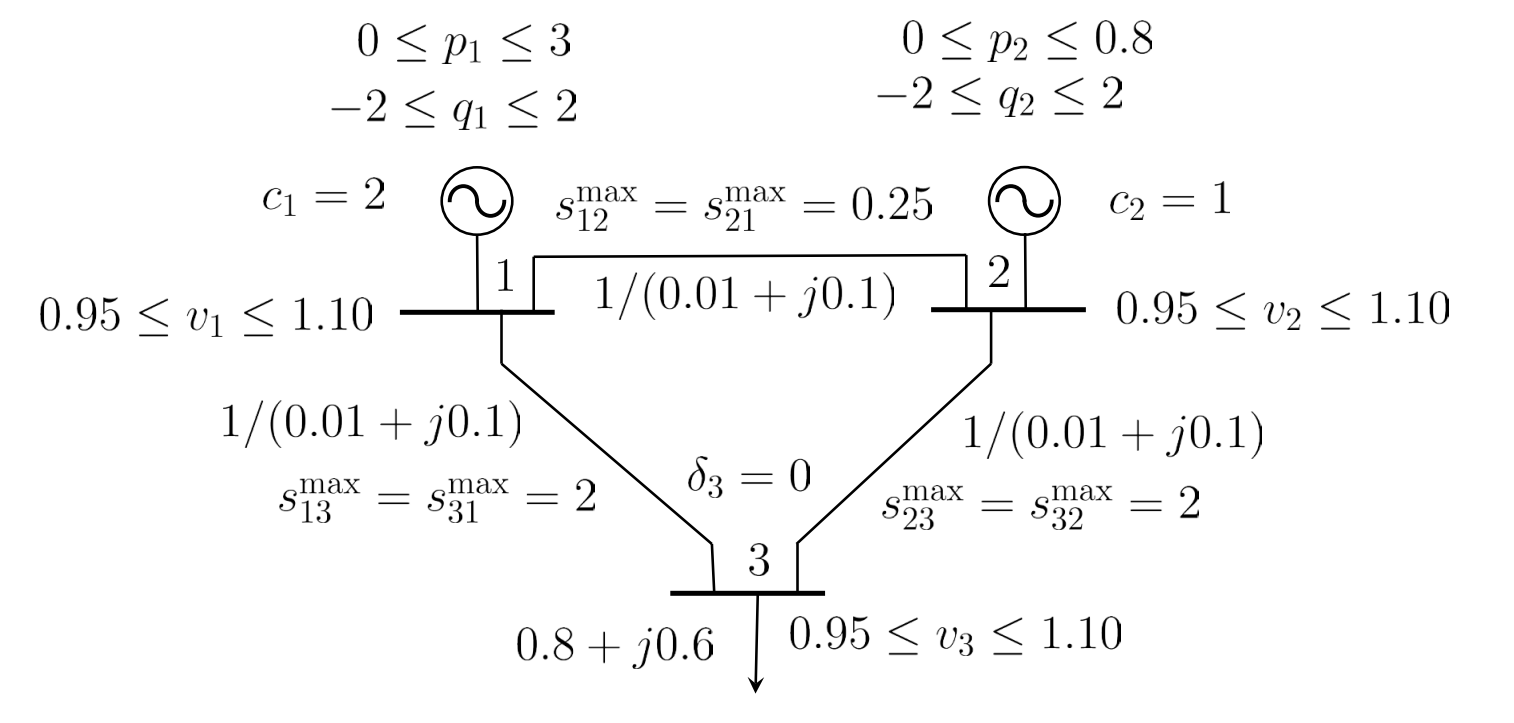

In [28]:
using JuMP
using Ipopt

z  = 0.01 + 0.1im
y  = 1/z          # ≈ 0.99 - 9.9im

G  = real(y)      # condutância
B  = imag(y)      # susceptância


s12_max = 0.25
s13_max = 2.0
s23_max = 2.0


Pd3 = 0.8
Qd3 = 0.6


model = Model(Ipopt.Optimizer)
set_attribute(model, "print_level", 0)


@variable(model, 0.95 <= v1 <= 1.10)
@variable(model, 0.95 <= v2 <= 1.10)
@variable(model, 0.95 <= v3 <= 1.10)

@variable(model, θ1)        
@variable(model, θ2)
@variable(model, θ3 == 0.0)   


@variable(model, 0.0 <= p1 <= 3.0)
@variable(model, -2.0 <= q1 <= 2.0)
@variable(model, 0.0 <= p2 <= 0.8)
@variable(model, -2.0 <= q2 <= 2.0)

# ── Função objetivo: minimizar custo de geração ───────────────────
# c1 = 2  (barra 1),  c2 = 1  (barra 2)
@objective(model, Min, 2*p1 + 1*p2)

# ── Fluxos de potência (forma polar) ─────────────────────────────
# P_ij = vi*vj*(G*cos(θi-θj) + B*sin(θi-θj)) - vi²*G
# Q_ij = vi*vj*(G*sin(θi-θj) - B*cos(θi-θj)) + vi²*B

# Balanço de potência ATIVA
# Barra 1: P1 = P12 + P13
@NLconstraint(model,
    p1 == v1^2*G
        - v1*v2*(G*cos(θ1-θ2) + B*sin(θ1-θ2))
        - v1*v3*(G*cos(θ1-θ3) + B*sin(θ1-θ3)))

# Barra 2: P2 = P21 + P23
@NLconstraint(model,
    p2 == v2^2*G
        - v2*v1*(G*cos(θ2-θ1) + B*sin(θ2-θ1))
        - v2*v3*(G*cos(θ2-θ3) + B*sin(θ2-θ3)))

# Barra 3 (carga): 0 = P3_inj + Pd3
@NLconstraint(model,
    0 == -Pd3
        + v3^2*G
        - v3*v1*(G*cos(θ3-θ1) + B*sin(θ3-θ1))
        - v3*v2*(G*cos(θ3-θ2) + B*sin(θ3-θ2)))

# Balanço de potência REATIVA
# Barra 1
@NLconstraint(model,
    q1 == -v1^2*B
        + v1*v2*(B*cos(θ1-θ2) - G*sin(θ1-θ2))
        + v1*v3*(B*cos(θ1-θ3) - G*sin(θ1-θ3)))

# Barra 2
@NLconstraint(model,
    q2 == -v2^2*B
        + v2*v1*(B*cos(θ2-θ1) - G*sin(θ2-θ1))
        + v2*v3*(B*cos(θ2-θ3) - G*sin(θ2-θ3)))

# Barra 3 (carga)
@NLconstraint(model,
    0 == -Qd3
        - v3^2*B
        + v3*v1*(B*cos(θ3-θ1) - G*sin(θ3-θ1))
        + v3*v2*(B*cos(θ3-θ2) - G*sin(θ3-θ2)))

# ── Limites de fluxo nas linhas  |S_ij|² ≤ s_ij_max² ────────────
# S_ij² = P_ij² + Q_ij²

# Linha 1-2
@NLexpression(model, P12,
    v1*v2*(G*cos(θ1-θ2) + B*sin(θ1-θ2)) - v1^2*G)
@NLexpression(model, Q12,
    -v1*v2*(B*cos(θ1-θ2) - G*sin(θ1-θ2)) + v1^2*B)
@NLconstraint(model, P12^2 + Q12^2 <= s12_max^2)

@NLexpression(model, P21,
    v2*v1*(G*cos(θ2-θ1) + B*sin(θ2-θ1)) - v2^2*G)
@NLexpression(model, Q21,
    -v2*v1*(B*cos(θ2-θ1) - G*sin(θ2-θ1)) + v2^2*B)
@NLconstraint(model, P21^2 + Q21^2 <= s12_max^2)

# Linha 1-3
@NLexpression(model, P13,
    v1*v3*(G*cos(θ1-θ3) + B*sin(θ1-θ3)) - v1^2*G)
@NLexpression(model, Q13,
    -v1*v3*(B*cos(θ1-θ3) - G*sin(θ1-θ3)) + v1^2*B)
@NLconstraint(model, P13^2 + Q13^2 <= s13_max^2)

@NLexpression(model, P31,
    v3*v1*(G*cos(θ3-θ1) + B*sin(θ3-θ1)) - v3^2*G)
@NLexpression(model, Q31,
    -v3*v1*(B*cos(θ3-θ1) - G*sin(θ3-θ1)) + v3^2*B)
@NLconstraint(model, P31^2 + Q31^2 <= s13_max^2)

# Linha 2-3
@NLexpression(model, P23,
    v2*v3*(G*cos(θ2-θ3) + B*sin(θ2-θ3)) - v2^2*G)
@NLexpression(model, Q23,
    -v2*v3*(B*cos(θ2-θ3) - G*sin(θ2-θ3)) + v2^2*B)
@NLconstraint(model, P23^2 + Q23^2 <= s23_max^2)

@NLexpression(model, P32,
    v3*v2*(G*cos(θ3-θ2) + B*sin(θ3-θ2)) - v3^2*G)
@NLexpression(model, Q32,
    -v3*v2*(B*cos(θ3-θ2) - G*sin(θ3-θ2)) + v3^2*B)
@NLconstraint(model, P32^2 + Q32^2 <= s23_max^2)

# ── Ponto inicial ─────────────────────────────────────────────────
set_start_value(v1, 1.0);  set_start_value(v2, 1.0);  set_start_value(v3, 1.0)
set_start_value(θ1, 0.0);  set_start_value(θ2, 0.0)
set_start_value(p1, 0.5);  set_start_value(p2, 0.5)
set_start_value(q1, 0.0);  set_start_value(q2, 0.0)

# ── Resolver ──────────────────────────────────────────────────────
optimize!(model)

# ── Resultados ────────────────────────────────────────────────────
println("="^45)
println("  OPF 3-Bus — Resultados")
println("="^45)
println("Status  : ", termination_status(model))
println("Custo   : ", round(objective_value(model), digits=6))
println()
println("  Geração:")
println("  P1 = $(round(value(p1),digits=4))  Q1 = $(round(value(q1),digits=4))")
println("  P2 = $(round(value(p2),digits=4))  Q2 = $(round(value(q2),digits=4))")
println()
println("  Tensões:")
println("  V1 = $(round(value(v1),digits=4))  δ1 = $(round(rad2deg(value(θ1)),digits=4))°")
println("  V2 = $(round(value(v2),digits=4))  δ2 = $(round(rad2deg(value(θ2)),digits=4))°")
println("  V3 = $(round(value(v3),digits=4))  δ3 = 0.0° (ref)")
println()
println("  Fluxos (|S|):")
println("  |S12| = $(round(sqrt(value(P12)^2+value(Q12)^2),digits=4))  (lim: $s12_max)")
println("  |S13| = $(round(sqrt(value(P13)^2+value(Q13)^2),digits=4))  (lim: $s13_max)")
println("  |S23| = $(round(sqrt(value(P23)^2+value(Q23)^2),digits=4))  (lim: $s23_max)")
println("="^45)

  OPF 3-Bus — Resultados
Status  : LOCALLY_INFEASIBLE
Custo   : -0.0

  Geração:
  P1 = -0.0  Q1 = -2.0
  P2 = -0.0  Q2 = -2.0

  Tensões:
  V1 = 0.95  δ1 = -4.6145°
  V2 = 0.95  δ2 = -6.2096°
  V3 = 0.95  δ3 = 0.0° (ref)

  Fluxos (|S|):
  |S12| = 0.25  (lim: 0.25)
  |S13| = 0.7231  (lim: 2.0)
  |S23| = 0.9728  (lim: 2.0)


# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [29]:
using JuMP
using Ipopt
using Statistics   
# ── Dados ─────────────────────────────────────────────────────────
X = [1.0  0.5  1.2;
     2.0  1.0  2.1;
     3.0  1.5  2.9;
     4.0  2.0  3.8;
     5.0  2.5  4.5]

y = [2.0, 3.9, 6.1, 8.0, 9.8]

n = size(X, 1)  # observações
p = size(X, 2)  # features

# ── Modelo ────────────────────────────────────────────────────────
model = Model(Ipopt.Optimizer)
set_attribute(model, "print_level", 0)

@variable(model, β0)
@variable(model, β[1:p])

# Minimizar soma dos quadrados dos resíduos
@NLobjective(model, Min,
    sum((y[i] - β0 - sum(X[i,j]*β[j] for j in 1:p))^2 for i in 1:n))

optimize!(model)

# ── Resultados ────────────────────────────────────────────────────
β0_val = value(β0)
β_val  = value.(β)

println("="^40)
println("  Regressão Linear — Resultados")
println("="^40)
println("β0 = ", round(β0_val, digits=6))
for j in 1:p
    println("β$j = ", round(β_val[j], digits=6))
end
println()
println("Modelo: ŷ = $(round(β0_val,digits=4))",
        " + $(round(β_val[1],digits=4))·x1",
        " + $(round(β_val[2],digits=4))·x2",
        " + $(round(β_val[3],digits=4))·x3")
println()
println("  Predições vs Real:")
println("  i   ŷ        y     resíduo")
for i in 1:n
    ŷ = β0_val + sum(X[i,j]*β_val[j] for j in 1:p)
    println("  $i   $(round(ŷ,digits=4))   $(y[i])   $(round(y[i]-ŷ, digits=6))")
end

# SSE e R²
ŷ_all = [β0_val + sum(X[i,j]*β_val[j] for j in 1:p) for i in 1:n]
SSE   = sum((y[i] - ŷ_all[i])^2 for i in 1:n)
SST   = sum((y[i] - mean(y))^2   for i in 1:n)
R²    = 1 - SSE/SST

println()
println("  SSE = ", round(SSE, digits=8))
println("  R²  = ", round(R², digits=8))
println("="^40)

  Regressão Linear — Resultados
β0 = -0.285455
β1 = 1.032727
β2 = 0.516364
β3 = 0.818182

Modelo: ŷ = -0.2855 + 1.0327·x1 + 0.5164·x2 + 0.8182·x3

  Predições vs Real:
  i   ŷ        y     resíduo
  1   1.9873   2.0   0.012727
  2   4.0145   3.9   -0.114545
  3   5.96   6.1   0.14
  4   7.9873   8.0   0.012727
  5   9.8509   9.8   -0.050909

  SSE = 0.03563636
  R²  = 0.99908277


# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [ ]:
using JuMP
using HiGHS

# ── Dados ─────────────────────────────────────────────────────────
# Scores de capacidade (designers × projetos)
e = [90  80  10  50;
     60  70  50  65;
     70  40  80  85]

# Horas requeridas por projeto
R = [70, 50, 85, 35]

# Horas máximas por designer
H_max = 80

n_eng  = 3   # designers
n_proj = 4   # projetos

# ── Modelo ────────────────────────────────────────────────────────
model = Model(HiGHS.Optimizer)
set_attribute(model, "output_flag", false)

# H[i,j] = horas do designer i no projeto j
@variable(model, H[1:n_eng, 1:n_proj] >= 0)

# Objetivo: maximizar score total ponderado
@objective(model, Max,
    sum(H[i,j] * e[i,j] for i in 1:n_eng, j in 1:n_proj))

# Restrição 1: cada designer tem no máximo 80h disponíveis
for i in 1:n_eng
    @constraint(model, sum(H[i,j] for j in 1:n_proj) <= H_max)
end

# Restrição 2: cada projeto deve receber ao menos R[j] horas
for j in 1:n_proj
    @constraint(model, sum(H[i,j] for i in 1:n_eng) >= R[j])
end

# ── Resolver ──────────────────────────────────────────────────────
optimize!(model)

# ── Resultados ────────────────────────────────────────────────────
H_val = value.(H)

println("="^55)
println("  Alocação Ótima de Designers — Resultados")
println("="^55)
println("Status      : ", termination_status(model))
println("Score total : ", round(objective_value(model), digits=2))
println()

# Tabela de alocação
header = "Designer |  Proj1   Proj2   Proj3   Proj4 | Total"
println(header)
println("-"^55)
for i in 1:n_eng
    total = sum(H_val[i,j] for j in 1:n_proj)
    vals  = join([lpad(round(H_val[i,j], digits=1), 7) for j in 1:n_proj], " ")
    println("    $i    | $vals  | $(round(total, digits=1))h")
end
println("-"^55)

# Horas totais por projeto
totais = [sum(H_val[i,j] for i in 1:n_eng) for j in 1:n_proj]
println("Required | ", join([lpad(R[j], 7) for j in 1:n_proj], " "), "  |")
println("Allocated| ", join([lpad(round(totais[j],digits=1), 7) for j in 1:n_proj], " "), "  |")
println("="^55)

# Score por projeto
println("\n  Score por projeto:")
for j in 1:n_proj
    score_j = sum(H_val[i,j] * e[i,j] for i in 1:n_eng)
    println("  Projeto $j : $(round(score_j, digits=2))")
end


  Alocação Ótima de Designers — Resultados
Status      : OPTIMAL
Score total : 18825.0

Designer |  Proj1   Proj2   Proj3   Proj4 | Total
-------------------------------------------------------
    1    |    70.0    10.0     0.0     0.0  | 80.0h

# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [ ]:
using JuMP
using HiGHS

# ── Dados ─────────────────────────────────────────────────────────
#              Apple  Bread  Milk   Egg
custo     = [1.00,  0.50,  2.00,  0.30]
calorias  = [100,   200,   150,   70  ]
proteina  = [0.5,   4.0,   8.0,   6.0 ]
vitaminas = [2.0,   0.0,   10.0,  0.0 ]

# Requisitos mínimos diários
cal_min = 500
prot_min = 50
vit_min  = 100

alimentos = ["Apple", "Bread", "Milk", "Egg"]
n = length(alimentos)

# ── Modelo ────────────────────────────────────────────────────────
model = Model(HiGHS.Optimizer)
set_attribute(model, "output_flag", false)

@variable(model, y[1:n] >= 0)

# Objetivo: minimizar custo total
@objective(model, Min, sum(custo[i] * y[i] for i in 1:n))

# Restrições nutricionais
@constraint(model, sum(calorias[i]  * y[i] for i in 1:n) >= cal_min)
@constraint(model, sum(proteina[i]  * y[i] for i in 1:n) >= prot_min)
@constraint(model, sum(vitaminas[i] * y[i] for i in 1:n) >= vit_min)

# ── Resolver ──────────────────────────────────────────────────────
optimize!(model)

y_val = value.(y)

# ── Resultados ────────────────────────────────────────────────────
println("="^50)
println("  Problema da Dieta — Resultados")
println("="^50)
println("Status      : ", termination_status(model))
println("Custo mínimo: \$", round(objective_value(model), digits=4))
println()
println("  Quantidade de cada alimento:")
for i in 1:n
    println("  $(alimentos[i]) (y$i) = $(round(y_val[i], digits=4))")
end
println()

# Verificação dos nutrientes
cal_tot  = sum(calorias[i]  * y_val[i] for i in 1:n)
prot_tot = sum(proteina[i]  * y_val[i] for i in 1:n)
vit_tot  = sum(vitaminas[i] * y_val[i] for i in 1:n)

println("  Nutrientes obtidos vs requisito:")
println("  Calorias  : $(round(cal_tot,  digits=2))  >= $cal_min")
println("  Proteína  : $(round(prot_tot, digits=2))g >= $prot_min g")
println("  Vitaminas : $(round(vit_tot,  digits=2))% >= $vit_min %")
println("="^50)


# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [ ]:
using JuMP
using HiGHS

# Dados do problema
valores  = [120, 80, 60]   # Tent, Stove, Food
pesos    = [2.0, 1.0, 1.0] # em kg
capacidade = 3.5           # kg

# Criação do modelo
model = Model(HiGHS.Optimizer)

# Variáveis binárias: x[i] = 1 se o item i é escolhido
@variable(model, x[1:3], Bin)

# Função objetivo: maximizar o valor total
@objective(model, Max, sum(valores[i] * x[i] for i in 1:3))

# Restrição de capacidade
@constraint(model, sum(pesos[i] * x[i] for i in 1:3) <= capacidade)

# Resolver
optimize!(model)

# Resultados
itens = ["Tent", "Stove", "Food"]
println("Status: ", termination_status(model))
println("Valor total: \$", objective_value(model))
println("\nItens selecionados:")
for i in 1:3
    if value(x[i]) > 0.5
        println("  - $(itens[i]) (Valor: \$$(valores[i]), Peso: $(pesos[i])kg)")
    end
end
println("\nPeso total: ", sum(pesos[i] * value(x[i]) for i in 1:3), "kg")